In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
import glob
import xarray as xr
import os
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
import geopandas as gpd

In [2]:
ensemble = 'PGWm'
file_list = glob.glob("/glade/work/klblack/Chinook/River/arcticdata.io/data/10.18739/A25M62870/*fPGWm_Q.nc")
print(f"Processing ensemble number: {ensemble}")

Processing ensemble number: PGWm


# Eagle future river flow 

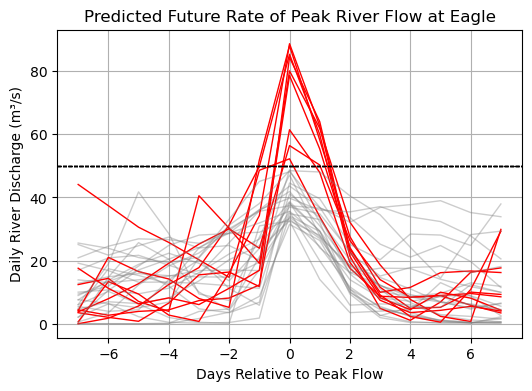

In [3]:
# Segment for Eagle
target_seg = 81014736

# Window around peak (days)
WINDOW_DAYS = 7

plt.figure(figsize=(6, 4))

FLOW_THRESHOLD = 50  # m^3/s

for file in file_list:
    try:
        year_str = os.path.basename(file).split("_")[0]
        year = int(year_str)

        ds = xr.open_dataset(file)
        flow = ds["IRFroutedRunoff"].sel(seg=target_seg).sortby("time")

        # Restrict to March-July
        start = pd.Timestamp(f"{year}-03-01")
        end   = pd.Timestamp(f"{year}-07-31 23:59:59")
        flow_year = flow.sel(time=slice(start, end))

        if flow_year.size < 10:
            ds.close()
            continue

        # Peak flow and time
        peak_index = flow_year.argmax("time")
        peak_flow = float(flow_year.isel(time=peak_index).values)
        peak_time = pd.to_datetime(flow_year.time.isel(time=peak_index).values)

        # Window around peak
        w_start = peak_time - pd.Timedelta(days=7)
        w_end   = peak_time + pd.Timedelta(days=7)
        flow_window = flow_year.sel(time=slice(w_start, w_end))

        if flow_window.size < 10:
            ds.close()
            continue

        relative_days = (
            flow_window.time.values - np.datetime64(peak_time)
        ) / np.timedelta64(1, "D")

        # ---- STYLE BASED ON PEAK MAGNITUDE ----
        if peak_flow > FLOW_THRESHOLD:
            color = "red"
            lw = 1
            alpha = 1.0
            label = f">{FLOW_THRESHOLD} m³/s"  # legend handled later
        else:
            color = "gray"
            lw = 1
            alpha = 0.4
            label = None

        plt.plot(
            relative_days,
            flow_window.values,
            color=color,
            linewidth=lw,
            alpha=alpha,
            label=label
        )
        plt.grid(True)
        plt.axhline(y=50, linestyle='--', color='black', linewidth=0.75)
        plt.title('Predicted Future Rate of Peak River Flow at Eagle')
        plt.xlabel('Days Relative to Peak Flow')
        plt.ylabel('Daily River Discharge (m³/s)')
        ds.close()

    except Exception as e:
        print(f"Skipping file {file} due to error: {e}")

/glade/derecho/scratch/klblack/tmp/ipykernel_104746/3903688728.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


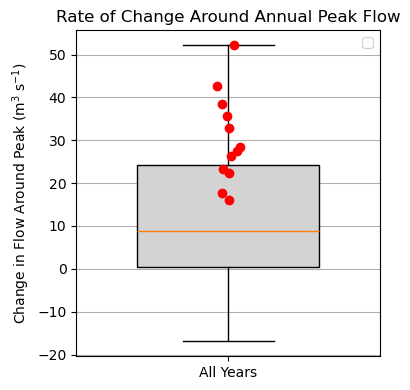

In [5]:
WINDOW_DAYS = 1

rows = []

for file in file_list:
    try:
        year = int(os.path.basename(file).split("_")[0])

        ds = xr.open_dataset(file)
        flow = ds["IRFroutedRunoff"].sel(seg=target_seg).sortby("time")

        # Restrict to calendar year
        start = pd.Timestamp(f"{year}-03-01")
        end   = pd.Timestamp(f"{year}-07-31 23:59:59")
        flow_year = flow.sel(time=slice(start, end))

        if flow_year.size < 10:
            ds.close()
            continue

        # Find annual peak
        peak_idx = flow_year.argmax("time")
        peak_time = pd.to_datetime(flow_year.time.isel(time=peak_idx).values)
        peak_flow = float(flow_year.isel(time=peak_idx).values)

        # ROC around peak
        t_minus = peak_time - pd.Timedelta(days=WINDOW_DAYS)
        t_plus  = peak_time + pd.Timedelta(days=WINDOW_DAYS)

        flow_minus = float(flow_year.sel(time=t_minus, method="nearest").values)
        flow_plus  = float(flow_year.sel(time=t_plus, method="nearest").values)

        roc = flow_plus - flow_minus

        rows.append({
            "Year": year,
            "PeakFlow": peak_flow,
            "RateOfChange": roc
        })

        ds.close()

    except Exception as e:
        print(f"Skipping {file}: {e}")

# Create dataframe
df = pd.DataFrame(rows).sort_values("Year").reset_index(drop=True)

# ---- Plot ----
ROC_THRESHOLD = 16

roc_all = df["RateOfChange"].values
roc_high = df.loc[df["RateOfChange"] > ROC_THRESHOLD, "RateOfChange"].values

plt.figure(figsize=(4, 4))

# Boxplot of all years
plt.boxplot(
    roc_all,
    positions=[0],
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray")
)

# Highlight only high-ROC years
rng = np.random.default_rng(0)
if len(roc_high) > 0:
    x = rng.normal(0, 0.03, size=len(roc_high))
    plt.scatter(
        x,
        roc_high,
        color="red",
        zorder=10
    )

plt.xticks([0], ["All Years"])
plt.ylabel(r"Change in Flow Around Peak (m$^3$ s$^{-1}$)")
plt.title("Rate of Change Around Annual Peak Flow")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.show()

# Galena future river flow

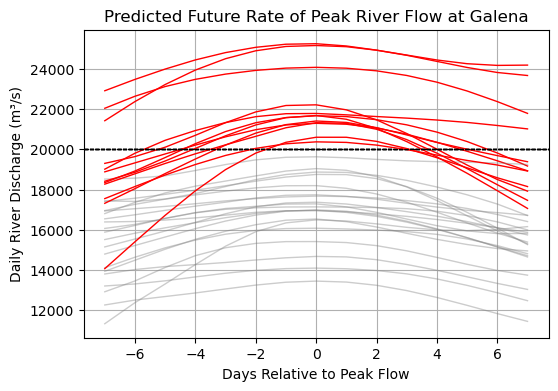

In [10]:
# Segment for Galena
target_seg = 81014218

# Window around peak (days)
WINDOW_DAYS = 7

plt.figure(figsize=(6, 4))

FLOW_THRESHOLD = 20000  # m^3/s

for file in file_list:
    try:
        year_str = os.path.basename(file).split("_")[0]
        year = int(year_str)

        ds = xr.open_dataset(file)
        flow = ds["IRFroutedRunoff"].sel(seg=target_seg).sortby("time")

        # Restrict to March-July
        start = pd.Timestamp(f"{year}-03-01")
        end   = pd.Timestamp(f"{year}-07-31 23:59:59")
        flow_year = flow.sel(time=slice(start, end))

        if flow_year.size < 10:
            ds.close()
            continue

        # Peak flow and time
        peak_index = flow_year.argmax("time")
        peak_flow = float(flow_year.isel(time=peak_index).values)
        peak_time = pd.to_datetime(flow_year.time.isel(time=peak_index).values)

        # Window around peak
        w_start = peak_time - pd.Timedelta(days=7)
        w_end   = peak_time + pd.Timedelta(days=7)
        flow_window = flow_year.sel(time=slice(w_start, w_end))

        if flow_window.size < 10:
            ds.close()
            continue

        relative_days = (
            flow_window.time.values - np.datetime64(peak_time)
        ) / np.timedelta64(1, "D")

        # ---- STYLE BASED ON PEAK MAGNITUDE ----
        if peak_flow > FLOW_THRESHOLD:
            color = "red"
            lw = 1
            alpha = 1.0
            label = f">{FLOW_THRESHOLD} m³/s"  # legend handled later
        else:
            color = "gray"
            lw = 1
            alpha = 0.4
            label = None

        plt.plot(
            relative_days,
            flow_window.values,
            color=color,
            linewidth=lw,
            alpha=alpha,
            label=label
        )
        plt.grid(True)
        plt.axhline(y=20000, linestyle='--', color='black', linewidth=0.75)
        plt.title('Predicted Future Rate of Peak River Flow at Galena')
        plt.xlabel('Days Relative to Peak Flow')
        plt.ylabel('Daily River Discharge (m³/s)')
        ds.close()

    except Exception as e:
        print(f"Skipping file {file} due to error: {e}")

/glade/derecho/scratch/klblack/tmp/ipykernel_104746/1468931678.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


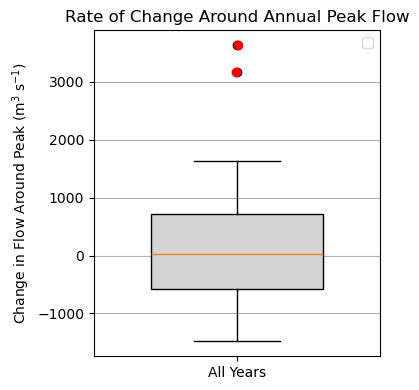

In [13]:
WINDOW_DAYS = 6

rows = []

for file in file_list:
    try:
        year = int(os.path.basename(file).split("_")[0])

        ds = xr.open_dataset(file)
        flow = ds["IRFroutedRunoff"].sel(seg=target_seg).sortby("time")

        # Restrict to calendar year
        start = pd.Timestamp(f"{year}-03-01")
        end   = pd.Timestamp(f"{year}-07-31 23:59:59")
        flow_year = flow.sel(time=slice(start, end))

        if flow_year.size < 10:
            ds.close()
            continue

        # Find annual peak
        peak_idx = flow_year.argmax("time")
        peak_time = pd.to_datetime(flow_year.time.isel(time=peak_idx).values)
        peak_flow = float(flow_year.isel(time=peak_idx).values)

        # ROC around peak
        t_minus = peak_time - pd.Timedelta(days=WINDOW_DAYS)
        t_plus  = peak_time + pd.Timedelta(days=WINDOW_DAYS)

        flow_minus = float(flow_year.sel(time=t_minus, method="nearest").values)
        flow_plus  = float(flow_year.sel(time=t_plus, method="nearest").values)

        roc = flow_plus - flow_minus

        rows.append({
            "Year": year,
            "PeakFlow": peak_flow,
            "RateOfChange": roc
        })

        ds.close()

    except Exception as e:
        print(f"Skipping {file}: {e}")

# Create dataframe
df = pd.DataFrame(rows).sort_values("Year").reset_index(drop=True)

# ---- Plot ----
ROC_THRESHOLD = 2661

roc_all = df["RateOfChange"].values
roc_high = df.loc[df["RateOfChange"] > ROC_THRESHOLD, "RateOfChange"].values

plt.figure(figsize=(4, 4))

# Boxplot of all years
plt.boxplot(
    roc_all,
    positions=[0],
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray")
)

# Highlight only high-ROC years
rng = np.random.default_rng(0)
if len(roc_high) > 0:
    x = rng.normal(0, 0.03, size=len(roc_high))
    plt.scatter(
        x,
        roc_high,
        color="red",
        zorder=10
    )

plt.xticks([0], ["All Years"])
plt.ylabel(r"Change in Flow Around Peak (m$^3$ s$^{-1}$)")
plt.title("Rate of Change Around Annual Peak Flow")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.show()